In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

import sys
sys.path.insert(0, '../src')
import utils.visualization as vis
from utils.preprocession import impute_dataframe, sparsen

from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

In [10]:
class RandomModel:
    def __init__(self):
        self.coef_ = np.random.randn(1, 2)
        self.intercept_ = np.random.randn(1)

    def predict_proba(self, X):
        logits = np.dot(X, self.coef_.T) + self.intercept_
        return (logits > 0).astype(int).flatten()

def binarize(array):
    np.random.seed(42)
    random_matrix = np.random.random(array.shape)
    return (random_matrix <= array).astype(int)



## Load Data

In [11]:
folder_name = '../data'
initial_data = 'candidates_reactions'

candidates = pd.read_csv(f'{folder_name}/candidates.csv', index_col=0)
coldstart = pd.read_csv(f'{folder_name}/{initial_data}.csv', index_col=0)
coldstart

,32214,32215,32216,32217,32218,32219,32220,32221,32222,32223,...,32279,32280,32281,32282,32283,32284,32285,32286,32287,32288
9,1.00,0.25,1.00,1.00,0.00,0.25,1.00,0.00,0.75,0.00,...,0.17,0.17,0.25,1.00,0.00,0.75,0.25,0.50,0.50,0.25
16,0.25,0.75,0.75,0.00,0.75,1.00,0.00,1.00,0.00,1.00,...,0.33,0.83,0.50,0.75,0.75,0.50,0.25,0.75,0.75,0.00
25,1.00,1.00,1.00,0.00,0.00,0.75,0.00,0.25,0.00,0.25,...,0.33,0.67,0.50,0.75,0.50,0.75,0.50,0.50,0.50,0.50
30,0.00,1.00,1.00,0.00,1.00,1.00,0.25,0.75,0.00,0.00,...,0.00,1.00,1.00,1.00,0.50,1.00,0.00,0.50,0.00,1.00
31,0.00,1.00,0.25,0.00,1.00,1.00,0.25,0.25,0.00,0.00,...,0.00,1.00,0.75,1.00,0.25,1.00,0.00,0.50,0.25,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5915,0.75,0.00,0.75,0.75,0.00,0.00,0.00,0.00,0.75,0.75,...,0.83,0.00,0.00,0.25,0.75,0.25,0.75,0.75,0.75,0.00
5918,0.75,0.75,1.00,0.75,0.75,0.00,0.00,1.00,0.75,0.75,...,0.33,0.33,0.50,0.75,0.25,0.50,0.50,0.50,0.50,0.75
5921,1.00,0.75,0.75,1.00,1.00,0.25,0.00,0.00,0.25,0.00,...,0.17,1.00,0.75,0.75,0.25,0.25,0.50,0.50,0.75,0.50
5922,0.00,1.00,1.00,0.00,1.00,1.00,0.00,1.00,0.00,0.25,...,0.00,1.00,0.75,1.00,0.50,1.00,0.00,0.50,0.00,1.00


## Train Model

In [12]:
imp_reactions = impute_dataframe(coldstart)
embedding = pd.DataFrame(PCA(n_components=2).fit_transform(imp_reactions), index=imp_reactions.index, columns=['x','y'])
centroid = embedding[['x', 'y']].mean()
embedding -= centroid
max_extent = np.abs(embedding[['x', 'y']]).max().max()  # Max of x and y absolute values
embedding /= max_extent

In [13]:

predictions = {}
models = {}
for task in coldstart.columns:
    model = LogisticRegression(random_state=0)
    mask = ~coldstart.loc[:, task].isna()
    train_data   = embedding[mask]
    train_labels = binarize(coldstart.loc[mask, task])
    if len(train_labels.unique()) == 2:
        model.fit(train_data, train_labels)
    else: 
        model = RandomModel()
        print(f"No model fitted for Feature {task}.")
    predictions[task] = model.predict_proba(embedding)[:,1]
    models[task] = model

predictions = pd.DataFrame(predictions, index=coldstart.index)
predictions


,32214,32215,32216,32217,32218,32219,32220,32221,32222,32223,...,32279,32280,32281,32282,32283,32284,32285,32286,32287,32288
9,0.930422,0.231063,0.595772,0.961336,0.447717,0.075601,0.188384,0.188125,0.822210,0.237838,...,0.488132,0.371594,0.261821,0.652957,0.237700,0.507441,0.501913,0.611037,0.713074,0.377711
16,0.266017,0.577827,0.769651,0.246212,0.452470,0.571375,0.180830,0.273334,0.314066,0.631636,...,0.484544,0.555564,0.501379,0.688859,0.560920,0.634254,0.437128,0.563666,0.536042,0.412011
25,0.529171,0.606386,0.724968,0.559706,0.640736,0.489664,0.229881,0.307648,0.431333,0.348744,...,0.389221,0.622948,0.512219,0.726221,0.435280,0.662590,0.388400,0.546177,0.529974,0.507832
30,0.095310,0.985125,0.831688,0.068977,0.985261,0.987084,0.522564,0.729229,0.056185,0.080297,...,0.091809,0.967264,0.921076,0.896779,0.591928,0.913452,0.125345,0.363831,0.165878,0.894539
31,0.169487,0.975294,0.808414,0.140806,0.979888,0.973514,0.496037,0.684261,0.090420,0.076092,...,0.106168,0.954419,0.892522,0.884793,0.534667,0.895207,0.144191,0.384708,0.202939,0.874064
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5915,0.703247,0.079598,0.671553,0.756897,0.058637,0.048293,0.080567,0.092107,0.760448,0.851089,...,0.777628,0.133223,0.145970,0.485050,0.430431,0.337132,0.694768,0.689312,0.805660,0.134062
5918,0.741740,0.360089,0.676157,0.796815,0.443606,0.208945,0.183757,0.219958,0.634738,0.396979,...,0.489749,0.444550,0.353394,0.666859,0.363055,0.560342,0.476434,0.592066,0.643894,0.388912
5921,0.647495,0.767727,0.708860,0.696308,0.863186,0.615711,0.324081,0.411730,0.420228,0.131892,...,0.251463,0.775401,0.625183,0.791153,0.364695,0.745311,0.293055,0.499006,0.448228,0.672015
5922,0.069275,0.985432,0.841885,0.046545,0.982729,0.988905,0.506343,0.725200,0.047534,0.105083,...,0.098813,0.966109,0.922698,0.893680,0.627371,0.912633,0.129163,0.365904,0.163384,0.887054


In [14]:
fit_rmse = np.sqrt(np.mean(np.square((coldstart - predictions))))
fit_rmse

0.2567811626931105

## Evaluation with different k

In [15]:
def evaluate_pca_lr(reactions, k=2):
    imp_reactions = impute_dataframe(reactions)
    embedding = pd.DataFrame(PCA(n_components=k).fit_transform(imp_reactions), index=imp_reactions.index)
    centroid = embedding.mean()
    embedding -= centroid
    max_extent = np.abs(embedding).max().max()
    embedding /= max_extent

    predictions = {}
    models = {}
    for task in reactions.columns:
        model = LogisticRegression(random_state=0)
        mask = ~reactions.loc[:, task].isna()
        train_data   = embedding[mask]
        train_labels = binarize(reactions.loc[mask, task])
        if len(train_labels.unique()) == 2:
            model.fit(train_data, train_labels)
        else: 
            model = RandomModel()
            print(f"No model fitted for Feature {task}.")
        predictions[task] = model.predict_proba(embedding)[:,1]
        models[task] = model

    predictions = pd.DataFrame(predictions, index=reactions.index)
    return np.sqrt(np.mean(np.square((coldstart - predictions))))

evaluate_pca_lr(coldstart, 2)

0.2567811626931105

In [18]:
values = list(range(1,11)) + list(range(11,21,2)) + list(range(21,40,4)) + list(range(41,75,8))
results = {}
for k in values:
    results[k] = evaluate_pca_lr(coldstart, k)
    print(str(k)+' ', end='')

1 2 3 4 5 6 7 8 9 10 11 13 15 17 19 21 25 29 33 37 41 49 57 65 73 

##### With different Sparsity

In [19]:
data_sparse = coldstart.apply(sparsen, p=0.85)
data_sparse.isna().mean().mean()

0.8503401360544218

In [20]:
results_sparse = {}
for k in values:
    results_sparse[k] = evaluate_pca_lr(data_sparse, k)
    print(str(k)+' ', end='')

1 2 3 4 5 6 7 8 9 10 11 13 15 17 19 21 25 29 33 37 41 49 57 65 73 

In [21]:
data_sparse = coldstart.apply(sparsen, p=0.5)
results_medium = {}
for k in values:
    results_medium[k] = evaluate_pca_lr(data_sparse, k)
    print(str(k)+' ', end='')

1 2 3 4 5 6 7 8 9 10 11 13 15 17 19 21 25 29 33 37 41 49 57 65 73 

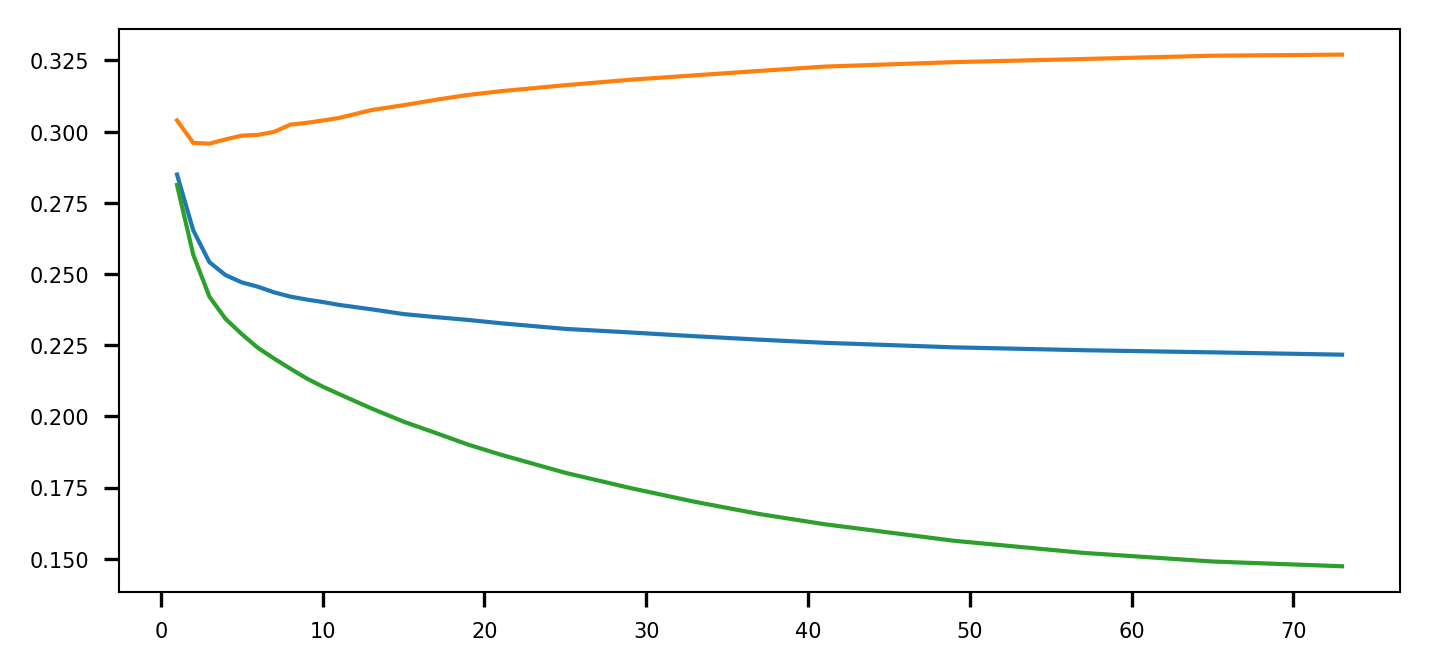

In [22]:
plt.plot(results_medium.keys(), results_medium.values())
plt.plot(results_sparse.keys(), results_sparse.values())
plt.plot(results.keys(), results.values())

## Visualization in case of 2D

/opt/miniconda3/envs/CSM/lib/python3.9/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


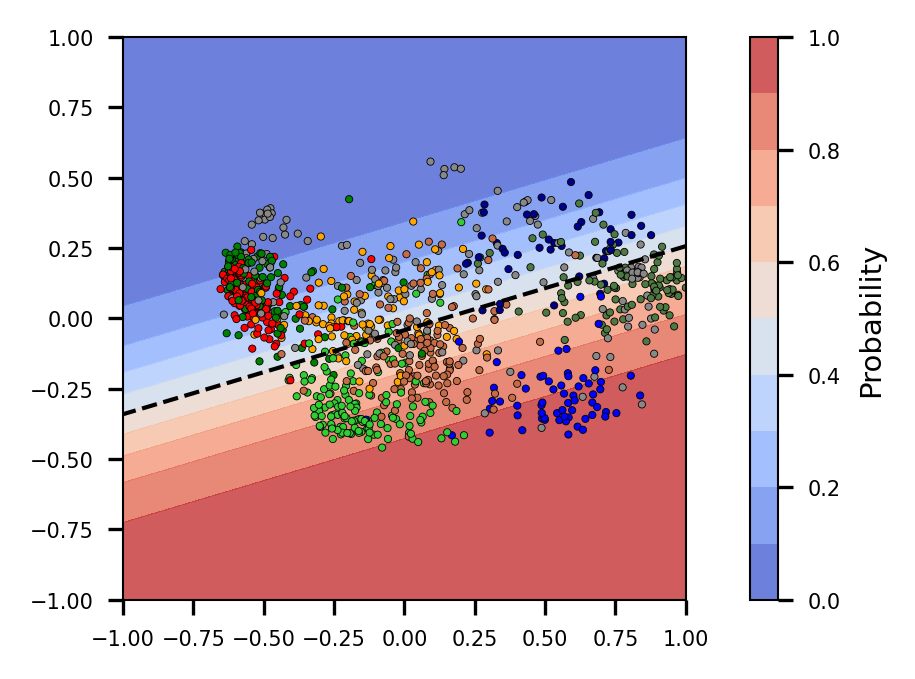

In [61]:
def show(q='32214'):
        fig, ax  = plt.subplots()
        xx, yy = np.meshgrid(np.linspace(-1,1,200),
                        np.linspace(-1,1,200))

        # Predict probabilities on the grid
        Z = models[q].predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]
        Z = Z.reshape(xx.shape)
        contour = ax.contourf(xx, yy, Z, alpha=0.8, cmap='coolwarm', levels=np.linspace(0, 1, 11),  zorder=1)
        ax.contour(xx, yy, Z, levels=[0.5], colors='black', linestyles='--')
        ax.scatter(embedding.x, embedding.y, 
                   c=candidates.color, 
                #    c=coldstart.loc[:,q],
                #    c=binarize(coldstart.loc[:,q]),
                #    c=predictions.loc[:,q], vmin=0, vmax=1,
                s=3, edgecolors='black', lw=0.2)

        colorbar = fig.colorbar(contour, ax=ax)
        colorbar.set_label('Probability')

        ax.set(xlim=[-1,1],
        ylim=[-1,1],
        aspect='equal'
                )

show()

/opt/miniconda3/envs/CSM/lib/python3.9/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


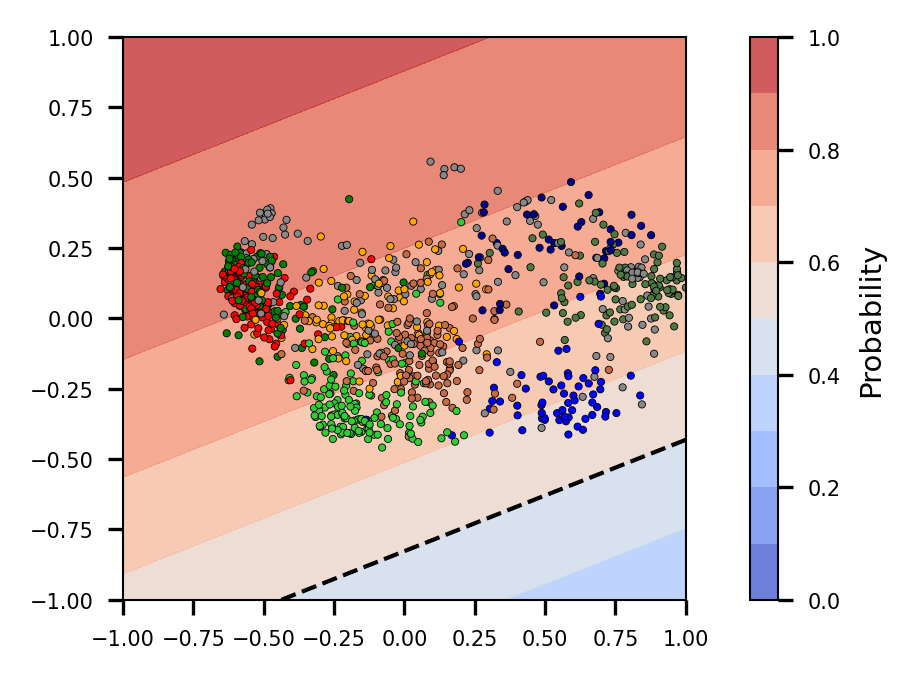

In [62]:
show('32216')